In [2]:
import pandas as pd

df = pd.read_excel("../data/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape 

(541909, 8)

In [6]:
df.columns 

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [9]:
# Check missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
# Drop missing values
df = df.dropna()

In [11]:
# Remove duplicates
df = df.drop_duplicates()

In [12]:
# Remove invalid data
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [13]:
# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [14]:
# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [15]:
# Top 10 countries by revenue
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [16]:
# Monthly trend
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df.groupby('Month')['Revenue'].sum()

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64

In [17]:
# Top customers
df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [19]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [20]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [21]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [22]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,182,4310.00,4,4,4,444
12348.0,75,31,1797.24,2,2,4,224
12349.0,19,73,1757.55,3,3,4,334
12350.0,310,17,334.40,1,1,2,112


In [23]:
rfm.sort_values('Monetary', ascending=False).head(10)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
14646.0,2,2076,280206.02,4,4,4,444
18102.0,1,431,259657.30,4,4,4,444
17450.0,8,336,194390.79,4,4,4,444
16446.0,1,3,168472.50,4,1,4,414
14911.0,1,5670,143711.17,4,4,4,444
12415.0,24,714,124914.53,3,4,4,344
14156.0,10,1395,117210.08,4,4,4,444
17511.0,3,963,91062.38,4,4,4,444
16029.0,39,241,80850.84,3,4,4,344


## 📊 Key Insights

* The United Kingdom generated the highest revenue among all countries, contributing significantly to total sales.
* A small group of customers contributed a large portion of total revenue, indicating a high-value customer segment.
* Monthly sales trends show fluctuations, with certain months experiencing peak sales.
* Top-performing products drive a major share of revenue, suggesting strong product demand concentration.
* RFM analysis identified high-value customers based on recency, frequency, and monetary metrics.

## 📌 Conclusion

The analysis highlights the importance of focusing on high-value customers and top-performing products to maximize revenue. Businesses can leverage these insights to improve customer retention and optimize sales strategies.


## 📊 Key Insights

- The majority of revenue comes from a small number of customers (high-value segment)
- Certain countries contribute most of the sales (e.g., UK dominates dataset)
- Top-selling products generate a significant portion of revenue
- Customer segmentation (RFM) helps identify loyal and at-risk customers

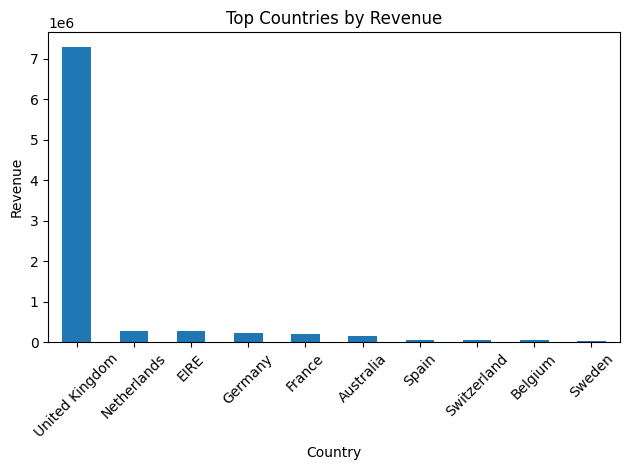

In [25]:
import matplotlib.pyplot as plt

country_sales = (
    df.groupby('Country')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales.plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


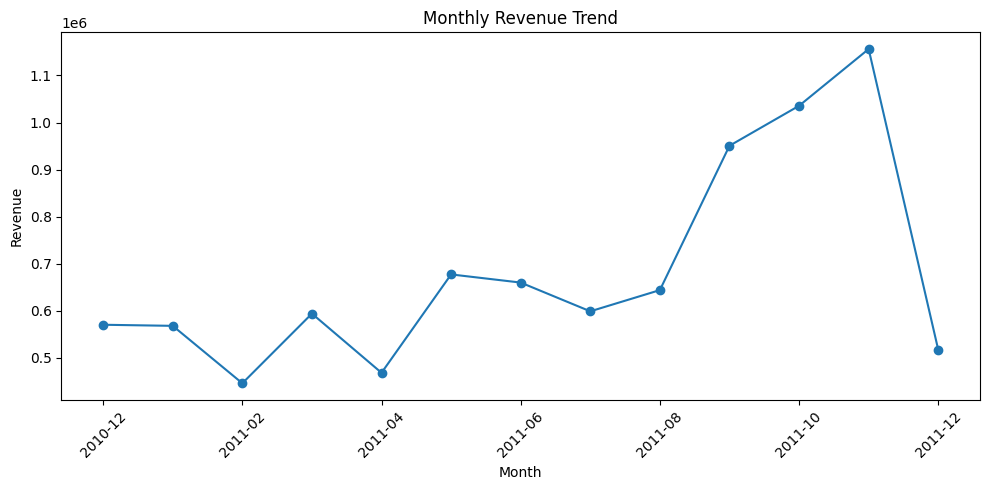

In [26]:
import matplotlib.pyplot as plt

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales.plot(figsize=(10, 5), marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


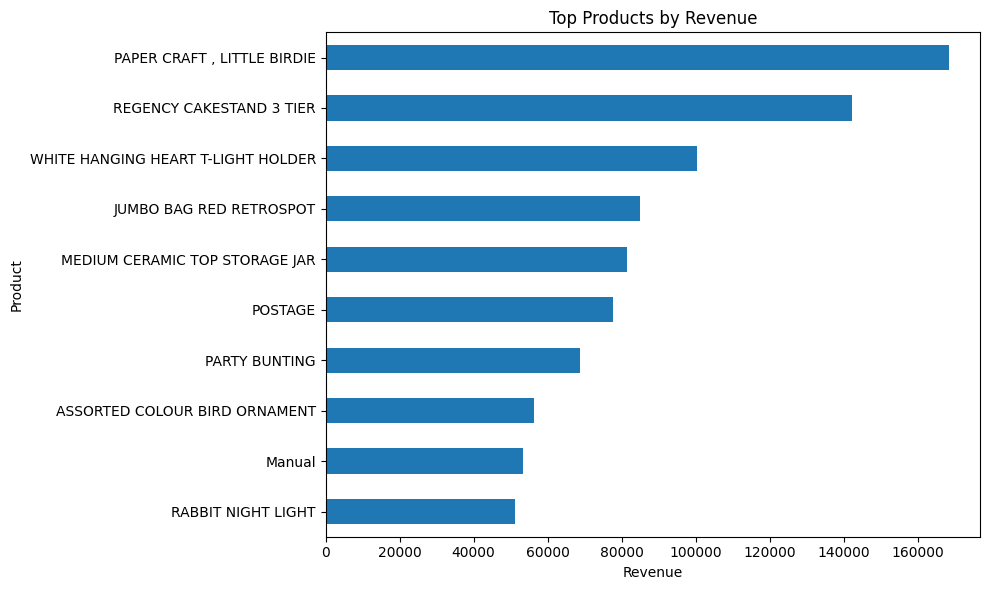

In [27]:
top_products = (
    df.groupby('Description')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title("Top Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


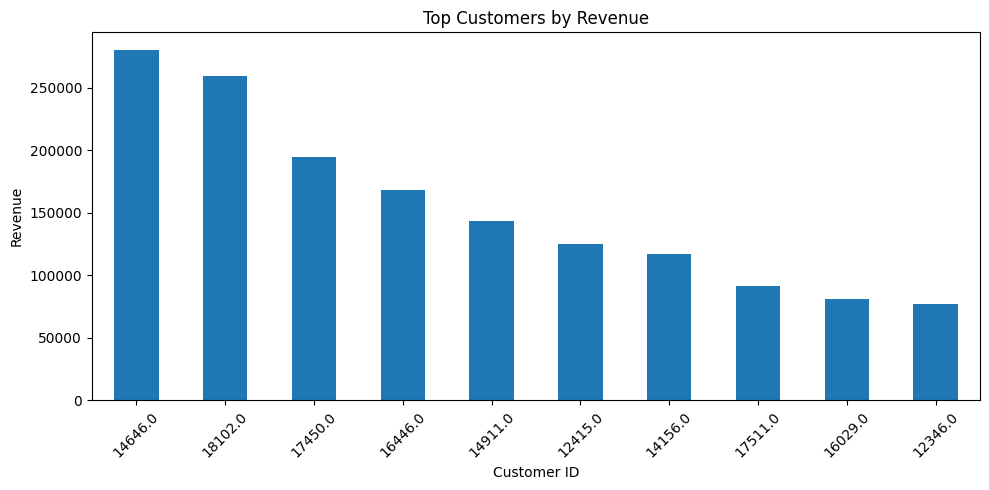

In [28]:
top_customers = (
    df.groupby('CustomerID')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers.plot(kind='bar', figsize=(10, 5))
plt.title("Top Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 📊 Key Insights

- The United Kingdom contributes the highest revenue
- A small number of customers generate most of the revenue
- Sales show seasonal trends across months
- Top products dominate total sales

## 📌 Conclusion

The business should focus on high-value customers and top-performing products to increase revenue.